In [1]:
import os 
import getpass
from typing import Annotated, Dict, List, Any
from typing_extensions import TypedDict

def setup_environment():
    """Setup your API KEYs"""
    if not os.environ.get("OPENAI_API_KEY"):
        openai_key = getpass.getpass("Enter your OPENAI API KEY")
        os.environ["OPENAI_API_KEY"] = openai_key

    if not os.environ.get("LANGSMITH_API_KEY"):
        langsmith_key = getpass.getpass("ENTER your LAngsmith API KEY")
        if langsmith_key:
            os.environ["LANGSMITH_API_KEY"] = langsmith_key
            os.environ["LANGCHAIN_TRACING_V2"] ="true"
            os.environ["LANGCHAIN_PROJECT"] = "Langgraph tutorial"
        else:
            print("skipping langsmith set up")


    print("Envioenment setup completed")
            
    
    

In [2]:
setup_environment()

Envioenment setup completed


### Different components of Langgraph

1. State
   . The Memory of your application
   Share data structure that persistance accross all steps
   * Can contain message, variabelse, flags or any data
  
2. Nodes

   * Individual functions or operations in your workflow
   * Each Nodes receives the current state and returns the updates
   * Think of them as "workers" that do specific tasks

3. Edges

   * Connections between the Nodes that define the flow
   * can be simple edge (A->B) or conditional (A->B or C based on the condition)

4. Graph

   * The ccomplete workflow combining nodes and edges
   * 

In [3]:
from langgraph.graph import StateGraph , START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage


class State(TypedDict):
    # messages will store our conversation history
    ### add_messages is a special function  that append new message instead of replacing them

    messages: Annotated[list, add_messages]



In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model = "gpt-4o",
    temperature= 0.7
)

llm.invoke("Hi").content

'Hello! How can I assist you today?'

In [5]:
print(f"Model: {llm.model_name}")

Model: gpt-4o


### step-3 create the chatbot Node

A **node** is a function that:
1. Takes the current state as input
2. does some work (like calling the LLM)
3. Return updates to state


In [6]:
def chatbot_node(state: State) -> Dict[str, Any]:
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}
    

### Step 4: Build Graph

Now we'll create a graph by:
1. Creating a StateGraph
2. Adding our Chatbot Node
3. Defining the flow
4. compiling it into a runnable application

In [7]:
graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot_node)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)


simple_chatbot = graph_builder.compile()


In [8]:
initial_state = {
        "messages": [HumanMessage(content="Hello! My name is vijay. What's your name?")]
    }
result = simple_chatbot.invoke(initial_state)

In [9]:
result['messages']

[HumanMessage(content="Hello! My name is vijay. What's your name?", additional_kwargs={}, response_metadata={}, id='4a6f5a2b-3555-4cfb-8a0e-84d22f81f130'),
 AIMessage(content="Hello Vijay! I'm an AI language model created by OpenAI, and I don't have a personal name, but you can call me Assistant. How can I help you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 19, 'total_tokens': 54, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BqEtTlpraKv9XQdG3XBjHsG4kmcg4', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--af11f432-273a-40a5-9bae-bf73f8bbb3c8-0', usage_metadata={'input_tokens': 19, 'output_tokens': 35, 'total_tokens': 54, 'input_tok

In [10]:
for i, message in enumerate(result['messages']):
    if isinstance(message, HumanMessage):
        print(f"Human: {message.content}")

    if isinstance(message, AIMessage):
        print(f"AI: {message.content}")

    
    

Human: Hello! My name is vijay. What's your name?
AI: Hello Vijay! I'm an AI language model created by OpenAI, and I don't have a personal name, but you can call me Assistant. How can I help you today?


In [11]:
def test_simple(user_input):
    initial_state = {
        "messages": [HumanMessage(content=user_input)]
    }
    result = simple_chatbot.invoke(initial_state)

    for i, message in enumerate(result['messages']):
        if isinstance(message, HumanMessage):
            print(f"Human: {message.content}")
    
        if isinstance(message, AIMessage):
            print(f"AI: {message.content}")

    # return result
    
    

In [12]:
test_simple("What is the GATE cutoff for mechanical Student")

Human: What is the GATE cutoff for mechanical Student
AI: The GATE (Graduate Aptitude Test in Engineering) cutoff for Mechanical Engineering can vary each year based on several factors, including the difficulty level of the exam, the number of candidates appearing, and the number of available seats in institutions. As of my last update, here are some general points to consider:

1. **Yearly Variation**: The cutoff marks change every year. To get the most accurate and updated information, you should refer to the official GATE website or the organizing institute for the specific year you are interested in.

2. **Category-wise Cutoffs**: The cutoff is different for different categories (General, OBC, SC/ST, etc.). Typically, the General category has the highest cutoff, followed by OBC, and then SC/ST.

3. **Institutions**: Different institutions might have their own cutoffs based on the GATE score for admission into their postgraduate programs. Prestigious institutions like IITs and NITs 

In [13]:
test_simple("What is the PGCET cutoff for mechanical in UVCE")

Human: What is the PGCET cutoff for mechanical in UVCE
AI: The Postgraduate Common Entrance Test (PGCET) cutoff for mechanical engineering at University Visvesvaraya College of Engineering (UVCE) can vary each year based on several factors such as the number of applicants, the difficulty level of the exam, and seat availability. 

To get the most accurate and up-to-date information for a specific academic year, it is best to refer to the official Karnataka Examination Authority (KEA) website or contact UVCE directly. They usually publish detailed cutoff lists after the admission process is completed.


In [14]:
test_simple("what was my last question")

Human: what was my last question
AI: I'm unable to recall past interactions or questions. Could you please repeat or specify your question?


### Adding Memory with Checkpointings

The power of Langgraph really shines when we add ** persistant memory**. This allows our agent to :

- Remember conversations accross multiple interactios
- Resume from where it left off
- Handle long-running workflow
- support Human-in-loop


### What is checkpointing

**Checkpointing** automatically saves the state after each steps. when you invoke the graph again with the same 'thread_id'. it load the saved state and continue from there 

Think of it like a video game save system!!



In [15]:
!pip install langgraph-checkpoint-sqlite

In [16]:
from langgraph.checkpoint.sqlite import SqliteSaver

chekpointer = SqliteSaver.from_conn_string(":memory")



### Step 2: Create a chatbot with Memory




In [17]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()


In [18]:
graph_builder_with_memory = StateGraph(State)

graph_builder_with_memory.add_node("chatbot", chatbot_node)
graph_builder_with_memory.add_edge(START, "chatbot")
graph_builder_with_memory.add_edge("chatbot", END)

chatbot_with_memory = graph_builder_with_memory.compile(checkpointer=memory)



In [19]:
import uuid
unique_id = uuid.uuid4()
str(unique_id)
print(f"Unique ID for this conversation: {unique_id}")

Unique ID for this conversation: 04a692fe-2d12-48b6-b0fd-5d7a3b6e992a


In [20]:

unique_id = "876084aa-e677-4455-b9e8-7ad78fcdff7a"
def test_simple(user_input):
    
    config = {"configurable": {"thread_id":str(unique_id)}}
    result = chatbot_with_memory.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config
    )
    return result
    

In [21]:
test_simple("Hi I am vijay and I am planning to take generative AI Course")

{'messages': [HumanMessage(content='Hi I am vijay and I am planning to take generative AI Course', additional_kwargs={}, response_metadata={}, id='6f14d6cf-4a96-4b09-b9f2-59b7de3b03b3'),
  AIMessage(content='That sounds like an exciting opportunity, Vijay! Generative AI is a fascinating and rapidly evolving field with applications in areas such as art, music, natural language processing, and more. Here are a few things you might want to consider as you plan to take a course:\n\n1. **Course Content**: Make sure the course covers the topics you are interested in, such as neural networks, GANs (Generative Adversarial Networks), transformers, and other models used in generative AI.\n\n2. **Prerequisites**: Check if there are any prerequisites for the course. A background in machine learning, programming (especially Python), and some mathematical foundations (like linear algebra and calculus) can be very helpful.\n\n3. **Hands-On Experience**: Look for courses that offer practical, hands-on

In [22]:
test_simple("what is my name")

{'messages': [HumanMessage(content='Hi I am vijay and I am planning to take generative AI Course', additional_kwargs={}, response_metadata={}, id='6f14d6cf-4a96-4b09-b9f2-59b7de3b03b3'),
  AIMessage(content='That sounds like an exciting opportunity, Vijay! Generative AI is a fascinating and rapidly evolving field with applications in areas such as art, music, natural language processing, and more. Here are a few things you might want to consider as you plan to take a course:\n\n1. **Course Content**: Make sure the course covers the topics you are interested in, such as neural networks, GANs (Generative Adversarial Networks), transformers, and other models used in generative AI.\n\n2. **Prerequisites**: Check if there are any prerequisites for the course. A background in machine learning, programming (especially Python), and some mathematical foundations (like linear algebra and calculus) can be very helpful.\n\n3. **Hands-On Experience**: Look for courses that offer practical, hands-on

In [23]:
import uuid
unique_id = uuid.uuid4()

str(unique_id)

'ee2c5584-c4f2-44a1-89f1-7f1e74e4b16b'

### Tool Integration

Real AI agents needs to intract with the outside world! Let's add the tool calling capablities

### What are tool 
- search the web
- Query database
- send email
- perform calculations
- Access APIs



In [24]:
import math
math.__dict__.items()

dict_items([('__name__', 'math'), ('__doc__', 'This module provides access to the mathematical functions\ndefined by the C standard.'), ('__package__', ''), ('__loader__', <class '_frozen_importlib.BuiltinImporter'>), ('__spec__', ModuleSpec(name='math', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in')), ('acos', <built-in function acos>), ('acosh', <built-in function acosh>), ('asin', <built-in function asin>), ('asinh', <built-in function asinh>), ('atan', <built-in function atan>), ('atan2', <built-in function atan2>), ('atanh', <built-in function atanh>), ('cbrt', <built-in function cbrt>), ('ceil', <built-in function ceil>), ('copysign', <built-in function copysign>), ('cos', <built-in function cos>), ('cosh', <built-in function cosh>), ('degrees', <built-in function degrees>), ('dist', <built-in function dist>), ('erf', <built-in function erf>), ('erfc', <built-in function erfc>), ('exp', <built-in function exp>), ('exp2', <built-in function exp2>), ('expm1'

In [25]:
from langchain_core.tools import tool
import math

@tool
def calculator(expression: str) -> str:
    """
    Evaluate a mathematical expression safely.
    
    Args:
        expression: A mathematical expression to evaluate (e.g., "2 + 3 * 4")
        
    Returns:
        The result of the calculation
    """
    try:
        # Safe evaluation of mathematical expressions
        # Only allow basic math operations
        allowed_names = {
            k: v for k, v in math.__dict__.items() if not k.startswith("__")
        }
        allowed_names.update({"abs": abs, "round": round})
        
        result = eval(expression, {"__builtins__": {}}, allowed_names)
        return f"The result of {expression} is {result}"
    except Exception as e:
        return f"Error calculating {expression}: {str(e)}"

@tool  
def get_current_time() -> str:
    """Get the current time."""
    from datetime import datetime
    return f"Current time is: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
    

In [26]:
calculator("cos(0)")

C:\Users\vijay\AppData\Local\Temp\ipykernel_23804\354598837.py:1: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  calculator("cos(0)")


'The result of cos(0) is 1.0'

In [27]:
get_current_time("")

'Current time is: 2025-07-06 13:51:27'

In [28]:
from datetime import datetime
datetime.now().strftime('%Y-%m-%d %H:%M:%S')

'2025-07-06 13:51:27'

In [29]:
from langgraph.prebuilt import ToolNode
from langchain_core.messages import ToolMessage

tools = [calculator, get_current_time]
llm_with_tools = llm.bind_tools(tools)


llm_with_tools.invoke("Hi who is the current PM in India")

AIMessage(content='As of my last update, the Prime Minister of India is Narendra Modi. He has been in office since May 26, 2014.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 95, 'total_tokens': 125, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BqEv70nN8LE2mMdF19EMes5cDQkCP', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--3b4eb93c-d125-4344-b227-f422b1123ce1-0', usage_metadata={'input_tokens': 95, 'output_tokens': 30, 'total_tokens': 125, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [30]:
llm_with_tools.invoke("2+2")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_mlrZLaxPBiMSDZRrXZndydvQ', 'function': {'arguments': '{"expression":"2+2"}', 'name': 'calculator'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 90, 'total_tokens': 106, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BqEvSHFOoEEnsXVeXyILo1VVhC3hX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--652f7f08-27cf-4c71-b7ce-3acf915f4561-0', tool_calls=[{'name': 'calculator', 'args': {'expression': '2+2'}, 'id': 'call_mlrZLaxPBiMSDZRrXZndydvQ', 'type': 'tool_call'}], usage_metadata={'input_tokens': 90, 'output_tokens': 16, 'total_tokens': 106, 'input_token_details': {'aud

In [31]:
from langgraph.prebuilt import ToolNode
from langchain_core.messages import ToolMessage

tools = [calculator, get_current_time]
llm_with_tools = llm.bind_tools(tools)


def chatbot_with_tools(state: State) -> Dict[str, Any]:
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}



tool_node = ToolNode(tools)


    
    

In [32]:
from typing import Literal

def should_continue(state: State) -> Literal["tools", "__end__"]:
    """
    Determines if we should use tools or end the conversation

    Return:
         "tools" if the last message has tool calls
         "__end__" if we should end
    
    
    """
    last_message = state['messages'][-1]
    if hasattr(last_message, "tool_calls"):
        return "tools"
    else:
        return "__end__"
        
               
    

In [33]:

d = llm_with_tools.invoke("2+2")

# d= {"a":{"b": 3}}

hasattr(d, "tool_calls")

True

In [34]:
tools_graph_builder = StateGraph(State)
tools_graph_builder.add_node("chatbot", chatbot_with_tools)
tools_graph_builder.add_node("tools", tool_node)

tools_graph_builder.add_edge(START, "chatbot")
tools_graph_builder.add_conditional_edges(
    "chatbot",
    should_continue,
    {
        "tools": "tools",
        "__end__": END
    }
)

tools_graph_builder.add_edge("tools", END)
tool_chatbot = tools_graph_builder.compile(checkpointer=memory)

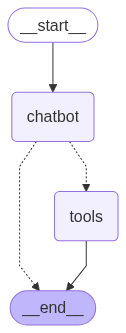

In [35]:
from IPython.display import Image, display

try:
    display(Image(tool_chatbot.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [36]:
import uuid
unique_id = uuid.uuid4()
print(f"unique ID:- {unique_id}")

unique ID:- 820ec043-e238-4fc4-aab3-792b12cf9690


In [37]:
def test_tool_chatbot(user_message):
    print("🛠️ Testing Tool-Enabled Chatbot")
    print("=" * 50)
    
    config = {"configurable": {"thread_id": "tool_test_1"}}
    
    # Test 1: Math calculation
    print("📝 Test 1: Math Calculation")
    result1 = tool_chatbot.invoke(
        {"messages": [HumanMessage(content=user_message)]},
        config
    )
    
    for message in result1["messages"]:
        if isinstance(message, HumanMessage):
            print(f"👤 Human: {message.content}")
        elif isinstance(message, AIMessage):
            if hasattr(message, 'tool_calls') and message.tool_calls:
                print(f"🤖 AI: [Calling tool: {message.tool_calls[0]['name']}]")
            else:
                print(f"🤖 AI: {message.content}")
        elif isinstance(message, ToolMessage):
            print(f"🔧 Tool: {message.content}")
    
    
    # return result2

# Test the tool-enabled chatbot
tool_result = test_tool_chatbot("who is PM of INdia")


🛠️ Testing Tool-Enabled Chatbot
📝 Test 1: Math Calculation
👤 Human: who is PM of INdia
🤖 AI: As of October 2023, the Prime Minister of India is Narendra Modi.


In [38]:
test_simple("2+2")

{'messages': [HumanMessage(content='2+2', additional_kwargs={}, response_metadata={}, id='915781c7-05cb-434b-ba78-3a9d46b0d372'),
  AIMessage(content='2 + 2 equals 4.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 10, 'total_tokens': 18, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BqEwVn2CWqE3IFrFzWVjO9Z3GVaVY', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--3e24a97d-c101-43bb-be49-1b3a8d27e604-0', usage_metadata={'input_tokens': 10, 'output_tokens': 8, 'total_tokens': 18, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

### Human in loop

Sometimes AI agents need human oversight or approval before actions. 

## What are the Intrupts

- Review what the agent plan to do
- Modify the state if neede
- Approve or reject actions
- provide additional guidence



In [39]:
class HumanLoopState(TypedDict):
    # messages will store our conversation history
    ### add_messages is a special function  that append new message instead of replacing them

    messages: Annotated[list, add_messages]
    ask_human: bool

In [40]:
@tool
def request_human_help(question:str)  -> str:
    """
    Request help from a human Supervison.
    Args:
    question: The question or situation where human help is needed

    Returns:
        Confirmation that help has been requested

    """
    return f"Human help requested for: {question}"


human_tools = [calculator, get_current_time, request_human_help]

llm_with_human_tools = llm.bind_tools(human_tools)


In [41]:
### create a node with Human assistant logic

def chatbot_with_human_help(state: HumanLoopState) -> Dict[str, Any]:
    messages = state["messages"]
    response = llm_with_human_tools.invoke(messages)
    ask_human = False
    if hasattr(response, "tool_calls"):
        for tool_call in response.tool_calls:
            if tool_call['name'] == 'request_human_help':
                ask_human = True
    return {"messages": [response], "ask_human": ask_human}



def human_node(state: HumanLoopState) -> Dict[str, Any]:
    """
    Human intervention node- this is where human can provide input
    """
    last_message = state['messages'][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        tool_call = last_message.tool_calls[0]
        if tool_call['name'] ==  "request_human_help":
            human_response = "I'have reviewed your question, Please process with calculation and provide a detail Explanation"
            tool_message = ToolMessage(
                content = human_response, 
                tool_call_id = tool_call['id']

            )
            return {"messages": [tool_message],
                    "ask_human": False}

    return {"ask_human": False} 
        
    

In [42]:
def route_human_loop(state: HumanLoopState) -> Literal["human", "tools", "__end__"]:
    """
    Route based on whether human help needed or tool cshould be called

    """
    if state.get("ask_human", False):
        return "human"

    messages = state['messages']
    last_message = messages[-1]

    if hasattr(last_message, "tool_calls"):
        for tool_call in last_message.tool_calls:
            if tool_call["name"] != "request_human_help":
                return "tools"
        return "human" 

    else:
        return "__end__"
    

    

    

In [43]:
d = {"a": 1, "b": 2}

In [44]:
d.get("c", False)

False

In [45]:
i = 2
def _check_if_else():
    if i==2:
        # print("conditioned matched")
        return "conditioned matched"
    else:
        return "conditioned not matched"

In [46]:
_check_if_else()

'conditioned matched'

In [47]:
human_loop_builder = StateGraph(HumanLoopState)
human_loop_builder.add_node("chatbot",chatbot_with_human_help)
human_loop_builder.add_node("tools", ToolNode(human_tools))
human_loop_builder.add_node("human", human_node)

human_loop_builder.add_edge(START, "chatbot")
human_loop_builder.add_conditional_edges(
    "chatbot",
    route_human_loop,
    {
        "human": "human",
        "tools": "tools", 
        "__end__": END
    }
)

human_loop_builder.add_edge("human", END)
human_loop_builder.add_edge("tools", END)

human_loop_chatbot = human_loop_builder.compile(
    checkpointer=memory,
    interrupt_before=["human"]

)
    
        

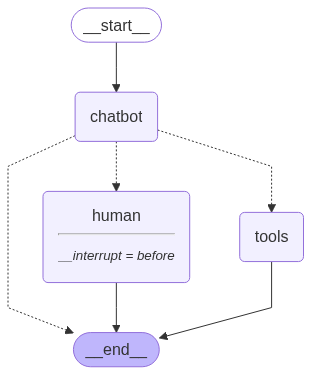

In [48]:
from IPython.display import Image, display

try:
    display(Image(human_loop_chatbot.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [49]:
def test_human_loop(user_message):
    print("🛠️ Testing Tool-Enabled Chatbot")
    print("=" * 50)
    
    config = {"configurable": {"thread_id": "human_loop_test"}}


    
    initial_result = human_loop_chatbot.invoke(
        {"messages": [HumanMessage(content=user_message)]},
        config
    )

    for message in initial_result["messages"]:
        if isinstance(message, HumanMessage):
            print(f"👤 Human: {message.content}")
        elif isinstance(message, AIMessage):
            if hasattr(message, 'tool_calls') and message.tool_calls:
                print(f"🤖 AI: [Requesting human help]")
            else:
                print(f"🤖 AI: {message.content}")

    state = human_loop_chatbot.get_state(config)
    if state.next == ("human",):
        print("In a real app, a human would now review and provide input.")
        final_result = human_loop_chatbot.invoke(None, config)
        
        # Show the final messages
        new_messages = final_result["messages"][len(initial_result["messages"]):]
        for message in new_messages:
            if isinstance(message, ToolMessage):
                print(f"👨‍💼 Human: {message.content}")
            elif isinstance(message, AIMessage):
                print(f"🤖 AI: {message.content}")
    
        return final_result
        
   

In [50]:
test_human_loop("add 2+2 and devide by 2")

🛠️ Testing Tool-Enabled Chatbot
👤 Human: add 2+2 and devide by 2
🤖 AI: [Requesting human help]


In [51]:
!pwd


'pwd' is not recognized as an internal or external command,
operable program or batch file.
